 ## Estadistica Aplicada
 
 Sesión 9B - 12 Septiembre
 
 Bryan Alejandro Estrada Rodriguez 1844554 
 
 Grupo: 42 
 

In [1]:
#Librerias Basicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
#Librerias Especializadas
from lifelines import CoxPHFitter
import seaborn as sns

In [4]:
# importar datos
df_cancer = pd.read_csv('cancer.csv')

In [5]:
df_cancer.head()

,inst,time,status,age,sex,ph.ecog,ph.karno,pat.karno,meal.cal,wt.loss
0,3.0,306,2,74,1,1.0,90.0,100.0,1175.0,NaN
1,3.0,455,2,68,1,0.0,90.0,90.0,1225.0,15.0
2,3.0,1010,1,56,1,0.0,90.0,90.0,NaN,15.0
3,5.0,210,2,57,1,1.0,90.0,60.0,1150.0,11.0
4,1.0,883,2,60,1,0.0,100.0,90.0,NaN,0.0


Los datos constan de 228 observaciones y 10 variables/columnas. La descripción de las variables es la siguiente:
inst: código de institución\
**time (d1)**: tiempo de supervivencia en días\
**status (d2)**: estado de censura 1 = censurado, 2 = muerto\
**age (i1)**: Edad en años\
**sex (i2)**: Masculino = 1 Femenino = 2\
**ph.ecog (i3)**: puntuación de rendimiento ECOG según la calificación del médico. 0 = asintomático, 1 = sintomático pero completamente ambulatorio, 2 = en cama <50% del día, 3 = en cama > 50% del día pero no encamado, 4 = encamado\
**ph.karno (i4)**: puntuación de desempeño de Karnofsky (mala = 0; buena = 100) calificada por el médico\
**pat.karno (i4)**: puntuación de rendimiento de Karnofsky según la calificación del paciente\
**meal.cal (i5)**: Calorías consumidas en las comidas\
**wt.loss (i6)**: Pérdida de peso en los últimos seis meses

In [6]:
## Se añadira un 3 paso 
# Depurar y estadisticas descriptivas
# Recodificar variables Dummy(las que toman 2 valores)
df_cancer['status'] = df_cancer['status']-1
df_cancer['sex'] = df_cancer['sex']-1
# status: 0=censurado, 1= Muerto
# sex: 0=Hombre, 2=Mujer


In [7]:
# Borrar la variable ins
df_cancer = df_cancer.drop('inst',axis=1)

In [8]:
## Verificar que todas las variables son numericas
df_cancer.dtypes
# Todas las variables son numerias (Enteras y decimales)

time           int64
status         int64
age            int64
sex            int64
ph.ecog      float64
ph.karno     float64
pat.karno    float64
meal.cal     float64
wt.loss      float64
dtype: object

In [9]:
## Contar los valores perdidos/faltantes (missing values)
df_cancer.isnull().sum()

time          0
status        0
age           0
sex           0
ph.ecog       1
ph.karno      1
pat.karno     3
meal.cal     47
wt.loss      14
dtype: int64

Si tenemos valores perdidos hay 2 opciones:
1. Eliminar las obsevaciones con valores
2. Imputar datos.

Se recomienda usar "imputar datos" cuando la muestra es muy pequeña, de lo contrario se puede "eliminar las observaciones con valores"

In [27]:
df_cancer['ph.karno'] = df_cancer['ph.karno'].fillna(df_cancer['ph.karno'].mean())
df_cancer['pat.karno'] = df_cancer['pat.karno'].fillna(df_cancer['pat.karno'].mean())
df_cancer['meal.cal'] = df_cancer['meal.cal'].fillna(df_cancer['meal.cal'].mean())
df_cancer['wt.loss'] = df_cancer['wt.loss'].fillna(df_cancer['wt.loss'].mean())
df_cancer = df_cancer.dropna()
df_cancer['ph.ecog'] = df_cancer['ph.ecog'].astype('int64')
df_cancer.isnull().sum()

time         0
status       0
age          0
sex          0
ph.ecog      0
ph.karno     0
pat.karno    0
meal.cal     0
wt.loss      0
dtype: int64

In [26]:
df_cancer.describe()

,time,status,age,sex,ph.ecog,ph.karno,pat.karno,meal.cal,wt.loss
count,227.000000,227.000000,227.000000,227.000000,227.000000,227.000000,227.000000,227.000000,227.000000
mean,306.264317,0.722467,62.458150,0.396476,0.951542,82.034971,79.999413,927.474067,9.734118
std,210.532764,0.448771,9.092045,0.490246,0.717872,12.240894,14.543193,358.375611,12.670492
min,5.000000,0.000000,39.000000,0.000000,0.000000,50.000000,30.000000,96.000000,-24.000000
25%,168.500000,0.000000,56.000000,0.000000,0.000000,80.000000,70.000000,768.000000,0.000000
50%,259.000000,1.000000,63.000000,0.000000,1.000000,80.000000,80.000000,928.779006,8.000000
75%,399.000000,1.000000,69.000000,1.000000,1.000000,90.000000,90.000000,1075.000000,15.000000
max,1022.000000,1.000000,82.000000,1.000000,3.000000,100.000000,100.000000,2600.000000,68.000000


In [11]:
df_cancer['sex'].value_counts()
#cuando tenemos una variable de 0 y 1 el promedio es la proporcion de unos

0    138
1     90
Name: sex, dtype: int64

El 39.47% son mujeres, El 72.36% de las personas fallecieron, la edad promedio es de 62.44, la edad mas joven es de 39 y la edad mas grande es de 82, La media de ph.karnon es mayor que la media de pat.karno que significa que el doctor evalua mejor la salud del paciente que el mismo paciente.

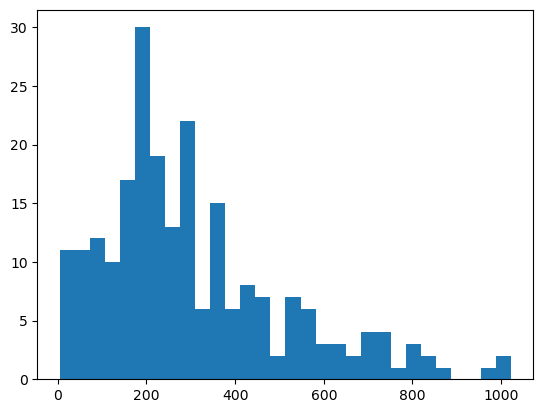

In [12]:
# histograma de variable independiente (tiempo de supervivencia y evento)
# histograma de tiempo de supervivencia 
plt.hist(df_cancer['time'],bins=30);

Text(0.5, 1.0, 'Histograma de la variable Time')

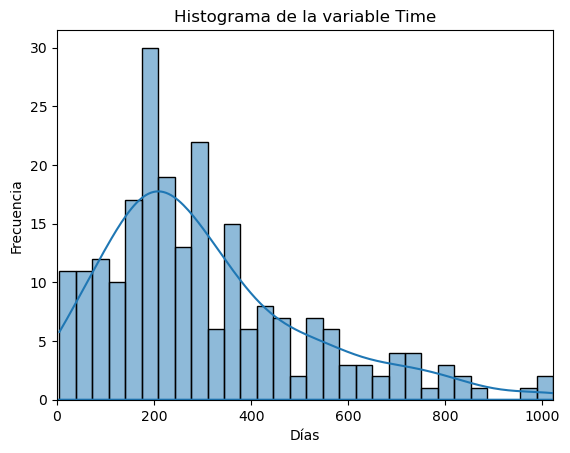

In [13]:
sns.histplot(df_cancer['time'],bins=30, kde=True)
sns.kdeplot(df_cancer['time'])
plt.xlim(0,1022)
plt.xlabel('Días')
plt.ylabel('Frecuencia')
plt.title('Histograma de la variable Time')

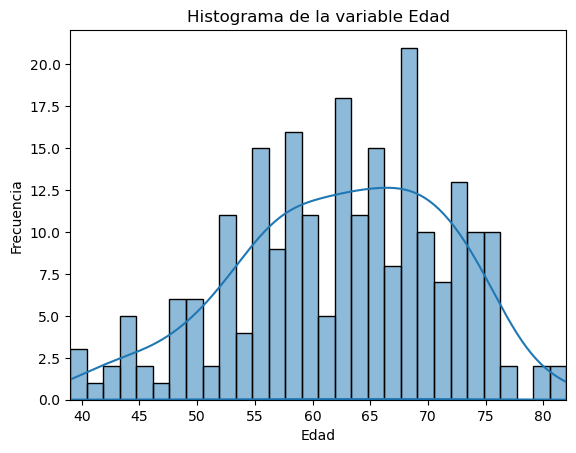

In [14]:
sns.histplot(df_cancer['age'],bins=30, kde=True)
sns.kdeplot(df_cancer['age'])
plt.xlim(39,82)
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.title('Histograma de la variable Edad');

In [41]:
## Estimar el modelo 
#cph1 = CoxPHFitter(variable,tiempo, evento)
cph1 = CoxPHFitter().fit(df_cancer,'time','status')
cph1.print_summary()

<lifelines.CoxPHFitter: fitted with 227 total observations, 63 right-censored observations>
             duration col = 'time'
                event col = 'status'
      baseline estimation = breslow
   number of observations = 227
number of events observed = 164
   partial log-likelihood = -725.64
         time fit was run = 2023-09-13 22:13:20 UTC

---
            coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                         
age         0.01       1.01       0.01            -0.01             0.03                 0.99                 1.03
sex        -0.59       0.56       0.17            -0.92            -0.25                 0.40                 0.78
ph.ecog     0.62       1.85       0.18             0.26             0.98                 1.29                 2.66
ph.karno    0.02       1.02       0.01            -0.00             0.03                 1.00                 1.03
pat.karno  -0.01       0.99       0.01            -0.03             0.00                 0.97                 1.00
meal.cal    0.00       1.00       0.00            -0.00             0.00                 1.00                 1.00
wt.loss    -0.01       0.99       0.01            -0.02             0.00                 0.98                 1.00

            cmp to     z      p   -log2(p)
covariate                                 
age           0.00  1.35   0.18       2.49
sex           0.00 -3.44 <0.005      10.76
ph.ecog       0.00  3.35 <0.005      10.28
ph.karno      0.00  1.66   0.10       3.36
pat.karno     0.00 -1.77   0.08       3.70
meal.cal      0.00  0.10   0.92       0.12
wt.loss       0.00 -1.73   0.08       3.57
---
Concordance = 0.65
Partial AIC = 1465.28
log-likelihood ratio test = 37.68 on 7 df
-log2(p) of ll-ratio test = 18.13

In [32]:
cph1

<lifelines.CoxPHFitter: fitted with 227 total observations, 63 right-censored observations>

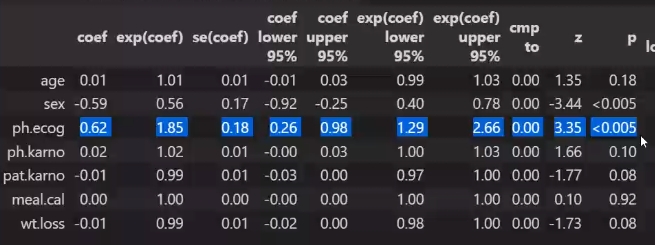

# AGE

P_valor 0.18 

No rechazamos H0, age no tiene efecto en el riesgo de morir de cancer.

# SEX

P_value < Alfa 
             
Rechazamos H0, Si es mujer reduce el riesgo de morir de cancer en un 44% respecto a los hombres 

exp(coef)>1 Aumenta el riesgo de sufrir el evento 
exp(coef)>1 disminuye el riesgo de sufrir el evento 

Si la B es positiva aumenta el riesgo de sufrir el evento 

Si la B es negativa dismunuye el riesgo de sufrir el evento 

# PH.KARNO

p_valor=0.10 
    
No rechazamos H0, ph.karno no tiene efecto dobre el riesgo de morir de cancer 

# PAT.KARNO 

p_valor=0.08 
No rechazamos H0, ph.karno no tiene efecto dobre el riesgo de morir de cancer

# MEAL 

p_valor= 0.92 

No rechazamos H0, ph.karno no tiene efecto dobre el riesgo de morir de cancer

# WT.LOSS

p_valor=0.08 
No rechazamos H0, ph.karno no tiene efecto dobre el riesgo de morir de cancer

# PH.ECOG 
p_valor=0.005 
Rechazamos H0. ph.ecog aumenta el riesgo de morir de cancer en 85% respecto a la categoria anterior 

exp(coef) = 1.85

1.85-1=0.85

## CARGAR UNA NUEVA BASE 


In [34]:
from lifelines.datasets import load_rossi

In [35]:
rossi = load_rossi()

In [36]:
rossi.head()

,week,arrest,fin,age,race,wexp,mar,paro,prio
0,20,1,0,27,1,0,0,1,3
1,17,1,0,18,1,0,0,1,8
2,25,1,0,19,0,1,0,1,13
3,52,0,1,23,1,1,1,1,1
4,52,0,0,19,0,1,0,1,3


In [39]:
cph2 = CoxPHFitter().fit(rossi, 'week','arrest')
cph2.print_summary()

<lifelines.CoxPHFitter: fitted with 432 total observations, 318 right-censored observations>
             duration col = 'week'
                event col = 'arrest'
      baseline estimation = breslow
   number of observations = 432
number of events observed = 114
   partial log-likelihood = -658.75
         time fit was run = 2023-09-13 22:12:43 UTC

---
            coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                         
fin        -0.38       0.68       0.19            -0.75            -0.00                 0.47                 1.00
age        -0.06       0.94       0.02            -0.10            -0.01                 0.90                 0.99
race        0.31       1.37       0.31            -0.29             0.92                 0.75                 2.50
wexp       -0.15       0.86       0.21            -0.57             0.27                 0.57                 1.30
mar        -0.43       0.65       0.38            -1.18             0.31                 0.31                 1.37
paro       -0.08       0.92       0.20            -0.47             0.30                 0.63                 1.35
prio        0.09       1.10       0.03             0.04             0.15                 1.04                 1.16

            cmp to     z      p   -log2(p)
covariate                                 
fin           0.00 -1.98   0.05       4.40
age           0.00 -2.61   0.01       6.79
race          0.00  1.02   0.31       1.70
wexp          0.00 -0.71   0.48       1.06
mar           0.00 -1.14   0.26       1.97
paro          0.00 -0.43   0.66       0.59
prio          0.00  3.19 <0.005       9.48
---
Concordance = 0.64
Partial AIC = 1331.50
log-likelihood ratio test = 33.27 on 7 df
-log2(p) of ll-ratio test = 15.37

fin no se rechaza H0 por que Pvalor de "fin=0.05", porque alfa es 0.05 y necesita ser estrictamente menor a alfa para rechazar H0

La edad reduce el riesgo de volver a ser arrestado. Por cada año de edad que se cumple se reduce le riesgo 6%

1-.94 = 0.06

race No rechazamos H0, no tienen efecto en el riesgo de volver a ser arrestado

Wexp, mar, paro pvalor>alfa no rechazamos H0 no tienen efecto en el riesgo de volver a ser arrestado

Prio, Rechazamos H0, por cada vez que te han arrestado el riesgo de que te vulvan a arrestar aumenta 10%

